# FNO implementation
1980 -2026 \
inputs: SSH, u_curr, v_curr, SLP, u_wind, v_wind, bathy \
outputs: SSH_(t+Δt), u_curr_(t+Δt), v_curr_(t+Δt)

## Import necessary lib

In [3]:
import torch
import torch.nn as nn
import torch.fft
import matplotlib.pyplot as plt
import numpy as np
import os
from neuralop.models import FNO
import xarray as xr

In [19]:
forcings = {}
#for year in range(1980):
    
    #data_forcing_feb = xr.open_dataset(f'data\\forcing\\fno_ERA5forcing_y{year}m02.nc')
    #data_forcing_mar = xr.open_dataset(f'data\\forcing\\fno_ERA5forcing_y{year}m03.nc')
    #data_forcing_apr = xr.open_dataset(f'data\\forcing\\fno_ERA5forcing_y{year}m04.nc')
    #data_forcing_may = xr.open_dataset(f'data\\forcing\\fno_ERA5forcing_y{year}m05.nc')
    #data_forcing_jun = xr.open_dataset(f'data\\forcing\\fno_ERA5forcing_y{year}m06.nc')
    #data_forcing_jul = xr.open_dataset(f'data\\forcing\\fno_ERA5forcing_y{year}m07.nc')
    #data_forcing_aug = xr.open_dataset(f'data\\forcing\\fno_ERA5forcing_y{year}m08.nc')
    #data_forcing_sep = xr.open_dataset(f'data\\forcing\\fno_ERA5forcing_y{year}m09.nc')
    #data_forcing_oct = xr.open_dataset(f'data\\forcing\\fno_ERA5forcing_y{year}m10.nc')
    #data_forcing_nov = xr.open_dataset(f'data\\forcing\\fno_ERA5forcing_y{year}m11.nc')
    #data_forcing_dec = xr.open_dataset(f'data\\forcing\\fno_ERA5forcing_y{year}m12.nc')
    #forcings[year] = (data_forcing_
    #jan, data_forcing_feb, data_forcing_mar, data_forcing_apr, data_forcing_may, data_forcing_jun, data_forcing_jul, data_forcing_aug, data_forcing_sep, data_forcing_oct, data_forcing_nov, data_forcing_dec)


data_forcing_jan = xr.open_dataset(f'data\\fno_ERA5forcing_y1980m01.nc')
msl_jan_1980 = data_forcing_jan["msl"]
u10_jan_1980 = data_forcing_jan["u10"]
v10_jan_1980 = data_forcing_jan["v10"]
# msl_feb_1980 = data_forcing_feb["msl"]
# u10_feb_1980 = data_forcing_feb["u10"]
# v10_feb_1980 = data_forcing_feb["v10"]
# msl_mar_1980 = data_forcing_mar["msl"]
# u10_mar_1980 = data_forcing_mar["u10"]
# v10_mar_1980 = data_forcing_mar["v10"]
# msl_apr_1980 = data_forcing_apr["msl"]
# u10_apr_1980 = data_forcing_apr["u10"]
# v10_apr_1980 = data_forcing_apr["v10"]
# msl_may_1980 = data_forcing_may["msl"]
# u10_may_1980 = data_forcing_may["u10"]
# v10_may_1980 = data_forcing_may["v10"]
# msl_jun_1980 = data_forcing_jun["msl"]
# u10_jun_1980 = data_forcing_jun["u10"]
# v10_jun_1980 = data_forcing_jun["v10"]
# msl_jul_1980 = data_forcing_jul["msl"]
# u10_jul_1980 = data_forcing_jul["u10"]
# v10_jul_1980 = data_forcing_jul["v10"]
# msl_aug_1980 = data_forcing_aug["msl"]
# u10_aug_1980 = data_forcing_aug["u10"]
# v10_aug_1980 = data_forcing_aug["v10"]

# data_forcing_feb_1983 = xr.open_dataset('data\\forcing\\fno_ERA5forcing_y1983m01.nc')

data_ssh = xr.open_dataset('data\\NAA10KM_1h_19800101_19801231_ssh.nc') # Sea surface height
data_ubar = xr.open_dataset('data\\NAA10KM_1h_19800101_19801231_ubar.nc') # U
data_vbar = xr.open_dataset('data\\NAA10KM_1h_19800101_19801231_vbar.nc') # V
data_bath = xr.open_dataset('data\\nordic_seas_domain_cfg.nc')

#forcings[1980][0]
print(data_bath)
print("Dataset attrs:", data_bath.attrs)
print("Coordinates:", list(data_bath.coords))
print("Variables:", list(data_bath.data_vars))
print(data_bath["bathy_metry"])
print("bathy_metry attrs:", data_bath["bathy_metry"].attrs)

print(data_ssh)
print("Dataset attrs:", data_ssh.attrs)
print("Coordinates:", list(data_ssh.coords))
print("Variables:", list(data_ssh.data_vars))
print(data_ssh["ssh"])
print("bathy_metry attrs:", data_ssh["ssh"].attrs)

print(msl_jan_1980)
print("Dataset attrs:", data_forcing_jan.attrs)
print("Coordinates:", list(data_forcing_jan.coords))
print("Variables:", list(data_forcing_jan.data_vars))


<xarray.Dataset> Size: 282MB
Dimensions:                (y: 280, x: 230, z: 75)
Coordinates:
    nav_lat                (y, x) float32 258kB ...
    nav_lon                (y, x) float32 258kB ...
Dimensions without coordinates: y, x, z
Data variables: (12/41)
    area                   (y, x) float64 515kB ...
    bathy_metry            (y, x) float32 258kB ...
    bottom_level           (y, x) int32 258kB ...
    e1f                    (y, x) float64 515kB ...
    e1t                    (y, x) float64 515kB ...
    e1u                    (y, x) float64 515kB ...
    ...                     ...
    ln_sco                 int32 4B ...
    ln_zco                 int32 4B ...
    ln_zps                 int32 4B ...
    nav_lev                (z) float32 300B ...
    smoothed_bottom_level  (y, x) int32 258kB ...
    top_level              (y, x) int32 258kB ...
Attributes:
    CDI:                        Climate Data Interface version 1.7.2 (http://...
    Conventions:                CF-1

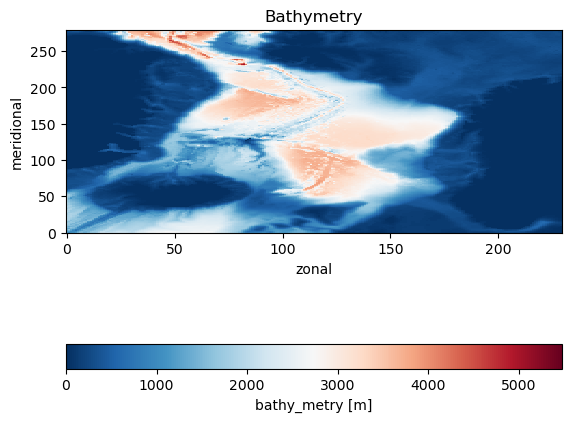

In [3]:
# Bathymetry is the depth of the ocean.
da = data_bath["bathy_metry"]
img = da.plot(cmap="RdBu_r", add_colorbar=True, cbar_kwargs={"orientation":"horizontal", "pad":0.3})

#.plot()
plt.xlabel("zonal")
plt.ylabel("meridional")
plt.title("Bathymetry")
plt.show()

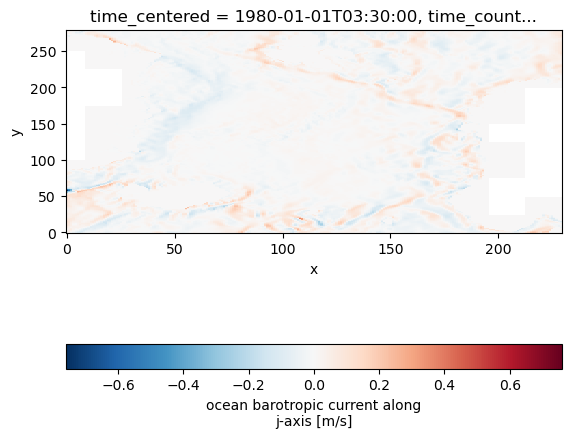

In [7]:
from matplotlib.colors import TwoSlopeNorm
da = data_vbar["vbar"].isel(time_counter=3
                            )

maxabs = np.nanmax(np.abs(da.values))
norm = TwoSlopeNorm(vmin=-maxabs, vcenter=0, vmax=maxabs)

img = da.plot(
    cmap="RdBu_r",
    norm=norm,
    add_colorbar=True,
    cbar_kwargs={"orientation": "horizontal", "pad": 0.3},
)
#plt.title("meridional barotropic current at time 0")
plt.show()

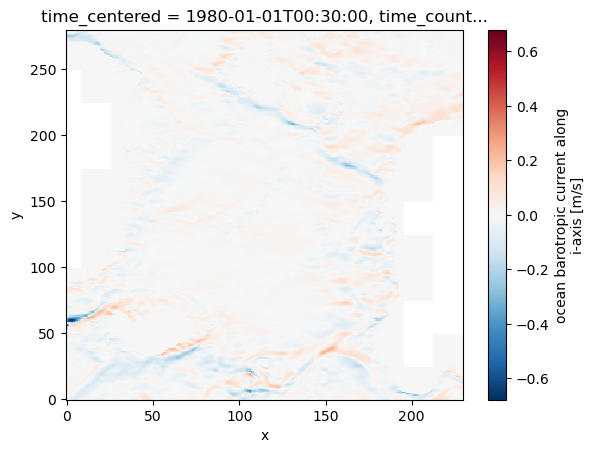

In [11]:
data_ubar["ubar"].isel(time_counter=0).plot()
#plt.title("Zonal barotropic current at time 0")
plt.show()

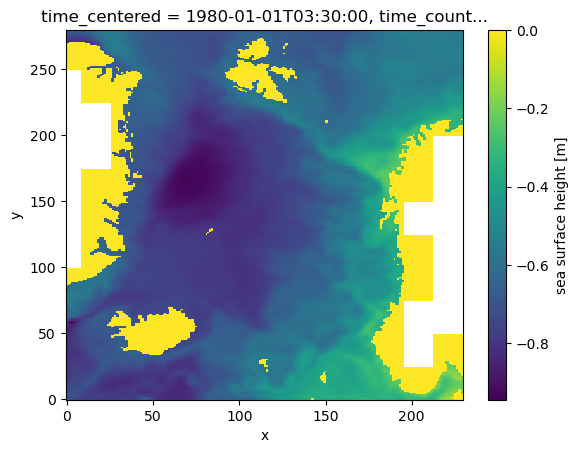

In [6]:
data_ssh["ssh"].isel(time_counter=3).plot()
#plt.title("Sea surface height at time 0")
plt.show()

In [16]:
ssh_time_mean = data_ssh["ssh"].mean(dim='time_counter', skipna=True)
print(ssh_time_mean)

<xarray.DataArray 'ssh' (y: 280, x: 230)> Size: 258kB
array([[-0.6509782 , -0.64699835, -0.64449686, ...,  0.        ,
         0.        ,  0.        ],
       [-0.65398216, -0.64887506, -0.6442372 , ...,  0.        ,
         0.        ,  0.        ],
       [-0.657307  , -0.6520612 , -0.6460741 , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.6397673 , -0.63642234, -0.63389504, ..., -0.54750323,
        -0.53938365, -0.53263605],
       [-0.6268851 , -0.62340564, -0.6205317 , ..., -0.5487125 ,
        -0.54130936, -0.5344862 ],
       [-0.61479133, -0.61138225, -0.608368  , ..., -0.5493359 ,
        -0.54319936, -0.5366842 ]], shape=(280, 230), dtype=float32)
Coordinates:
    nav_lat  (y, x) float32 258kB ...
    nav_lon  (y, x) float32 258kB ...
Dimensions without coordinates: y, x
Attributes:
    standard_name:       sea_surface_height_above_geoid
    long_name:           sea surface height
    units:               m
    online_operation:    average
  

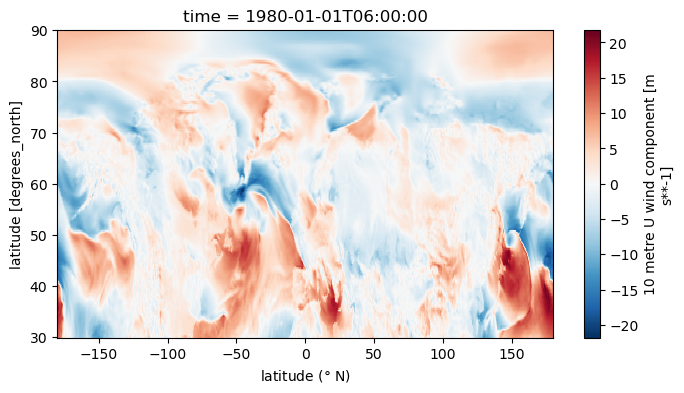

In [17]:

plt.rcParams['figure.figsize'] = [8, 4
                                  ]
data_forcing_jan["u10"].isel(time=2).plot(cmap="RdBu_r")
#plt.title("10 metre U wind component")
plt.xlabel("longitude ($\\degree$ E)")
plt.xlabel("latitude ($\\degree$ N)")

plt.show()

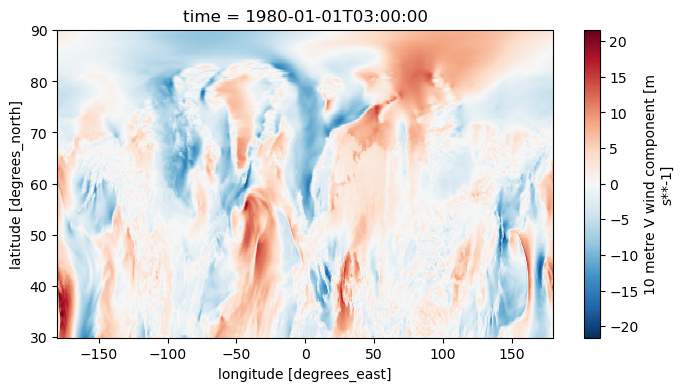

In [8]:
data_forcing_jan["v10"].isel(time=1).plot()
plt.show()

<xarray.DataArray 'lat' (lat: 241)> Size: 964B
array([90.  , 89.75, 89.5 , ..., 30.5 , 30.25, 30.  ],
      shape=(241,), dtype=float32)
Coordinates:
  * lat      (lat) float32 964B 90.0 89.75 89.5 89.25 ... 30.75 30.5 30.25 30.0
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          degrees_north
    axis:           Y <xarray.DataArray 'lon' (lon: 1440)> Size: 6kB
array([-180.  , -179.75, -179.5 , ...,  179.25,  179.5 ,  179.75],
      shape=(1440,), dtype=float32)
Coordinates:
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
Attributes:
    standard_name:  longitude
    long_name:      longitude
    units:          degrees_east
    axis:           X


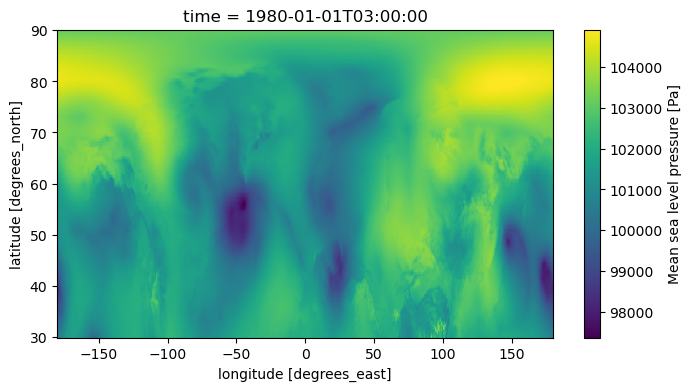

In [18]:
target = data_forcing_jan["msl"]
print(target.lat, target.lon)
target.isel(time=1).plot()
plt.show()

In [10]:
target = data_ssh
print(target["y"], target["x"])

<xarray.DataArray 'y' (y: 280)> Size: 2kB
[280 values with dtype=int64]
Dimensions without coordinates: y <xarray.DataArray 'x' (x: 230)> Size: 2kB
[230 values with dtype=int64]
Dimensions without coordinates: x


objective: emulating barotropic ocean currents (u, v) and sea surface height (ssh) of the next time step.
inputs: U10, v10, msl, bathymetry, and previous state of the ocean (u, v, ssh)

In [11]:
forcing_interp_jan = data_forcing_jan.interp(
    lat=data_ssh.nav_lat, 
    lon=data_ssh.nav_lon, 
    method='linear'
)


In [12]:
# Check actual shapes
print("data_forcing_jan['u10'].shape:", data_forcing_jan['u10'].shape)
print("data_forcing_jan['v10'].shape:", data_forcing_jan['v10'].shape)
print("data_forcing_jan['msl'].shape:", data_forcing_jan['msl'].shape)
print()

print("data_ssh['ssh'].shape:", data_ssh['ssh'].shape)
print("data_ssh['ssh'] variables:", data_ssh['ssh'].dims)
print()
print("data_ubar['ubar'].shape:", data_ubar['ubar'].shape)
print("data_ubar['ubar'] variables:", data_ubar['ubar'].dims)
print()
print("data_vbar['vbar'].shape:", data_vbar['vbar'].shape)
print("data_vbar['vbar'] variables:", data_vbar['vbar'].dims)

data_forcing_jan['u10'].shape: (248, 241, 1440)
data_forcing_jan['v10'].shape: (248, 241, 1440)
data_forcing_jan['msl'].shape: (248, 241, 1440)

data_ssh['ssh'].shape: (8784, 280, 230)
data_ssh['ssh'] variables: ('time_counter', 'y', 'x')

data_ubar['ubar'].shape: (8784, 280, 230)
data_ubar['ubar'] variables: ('time_counter', 'y', 'x')

data_vbar['vbar'].shape: (8784, 280, 230)
data_vbar['vbar'] variables: ('time_counter', 'y', 'x')


In [13]:
# Instead of concatenating all months in memory at once (MemoryError),
# process each month sequentially and collect the arrays.
months = [data_forcing_jan]

interp_list = []
for ds in months:
    # spatial interpolation for this month
    tmp = ds.interp(lat=data_ssh.nav_lat, lon=data_ssh.nav_lon, method='linear')
    # take only necessary variables and convert to numpy
    arr = np.stack([tmp['u10'].values, tmp['v10'].values, tmp['msl'].values], axis=1)
    # arr shape: (time, 3, y, x)
    interp_list.append(arr)
    print(f"Processed month shape: {arr.shape}")

# concatenate along time axis
forcing_all_np = np.concatenate(interp_list, axis=0)
print("Concatenated forcing array shape", forcing_all_np.shape)

# if desired, you can convert back to xarray later
# forcing_interp = xr.DataArray(forcing_all_np, dims=('time','var','y','x'))

# we'll use forcing_all_np when building inputs


Processed month shape: (248, 3, 280, 230)
Concatenated forcing array shape (248, 3, 280, 230)
